In [1]:
from matplotlib import pyplot as plt
import numpy as np
import membrane_reactor
import importlib
importlib.reload(membrane_reactor)
from membrane_reactor import MembraneReactor
import scipy.constants as const

#import warnings
#warnings.simplefilter("error")

def calculate_flows(GHSV, vol_reactor, sweep_ratio, H2_N2_ratio, T_STP = 273.15, P_STP = 101325.0):
    """
    Converts GHSV (1/h) and Geometry to F_ret_in and F_perm_in (mol/s).
    Includes H2:N2 ratio logic.
    """    
    # 1. Volumetric Flow at STP (Standard T=273.15K, P=101325 Pa)
    vol_flow_std = (GHSV * vol_reactor) / 3600.0
    
    # 2. Total Molar Flow (Ideal Gas Law at STP)
    F_ret_in = (P_STP * vol_flow_std) / (const.R * T_STP)
    
    # 4. Species Mole Fractions based on H2:N2 Ratio
    # Ratio R = H2/N2 -> H2 = R*N2 -> x_H2 + x_N2 = 1 (assuming pure feed for simplicity)
    # x_N2 * (R + 1) = 1  => x_N2 = 1 / (R + 1)
    y_N2_in = 1.0 / (H2_N2_ratio + 1.0)
    y_H2_in = 1.0 - y_N2_in
    
    # Note: If your defaults.py requires specific species fractions, 
    # you might need to adjust DEFAULTS['x_ret_in'] separately.
    
    # 5. Calculate Permeate Flow
    F_perm_in = F_ret_in * sweep_ratio
    
    return F_ret_in, F_perm_in, y_H2_in, y_N2_in

j: 0, g_norm: 68.99722434019107


/home/frankp/Codes/ammonia_synthesis_reactor/membrane_reactor.py:1013: RuntimeWarning: divide by zero encountered in scalar divide
  return j+1, g_norm, g_p_norm, False, g_norm/g_norm_init, g_p_norm/g_p_norm_init


j: 0, g_norm: 29.160424613617295
j: 1, g_norm: 4.491018012773916
j: 2, g_norm: 0.11704200479661853
j: 3, g_norm: 0.012914555513721672
j: 4, g_norm: 0.002834284394152197
Residence time retentate side: 301.86038105521743
Residence time permeate side: 10.811125899119354
j: 0, g_norm: 6.826612838545394
j: 1, g_norm: 157.55391254915034
j: 2, g_norm: 0.03864675353550559
j: 3, g_norm: 1.4989769380028954
j: 4, g_norm: 28029463724.313614
Reduced dt to 8.7662.
j: 0, g_norm: 6.570936167037005
j: 1, g_norm: 67.31560176052135
j: 2, g_norm: 0.07996931888413715
j: 3, g_norm: 1.7920631307341708
j: 4, g_norm: 1.6192412842055277
j: 5, g_norm: 0.2033179792711196
j: 6, g_norm: 0.01857463028364767
j: 7, g_norm: 0.010076283692891298
j: 8, g_norm: 0.0037734660636163236
Increasing timestep to dt = 10.519388552965037, t = 8.766157127470866
j: 0, g_norm: 0.06636842510804512
j: 1, g_norm: 0.016967357806189062
j: 2, g_norm: 0.006406635930202709
Increasing timestep to dt = 12.623266263558044, t = 19.28554568043590

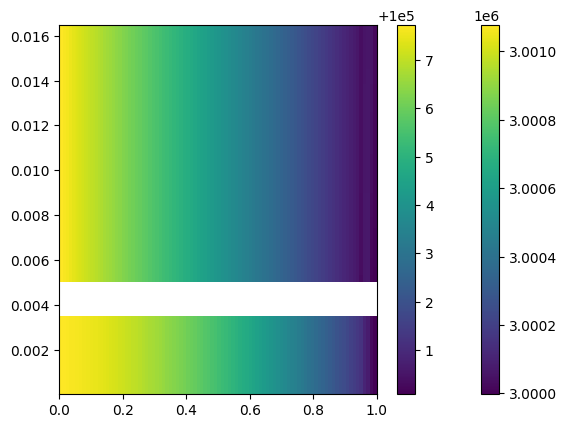

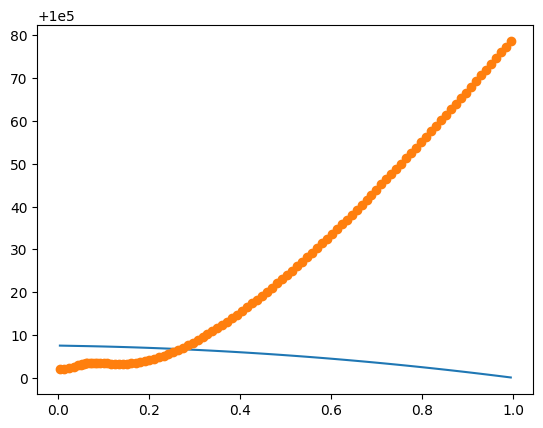

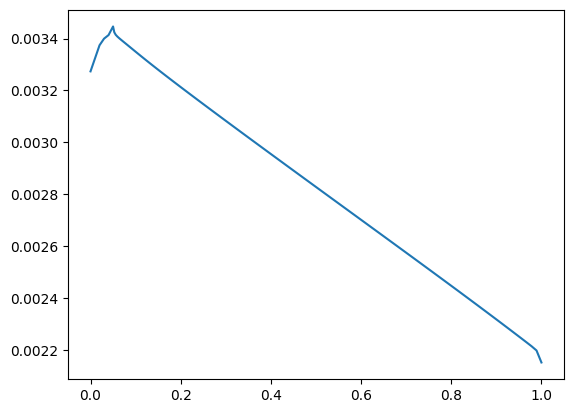

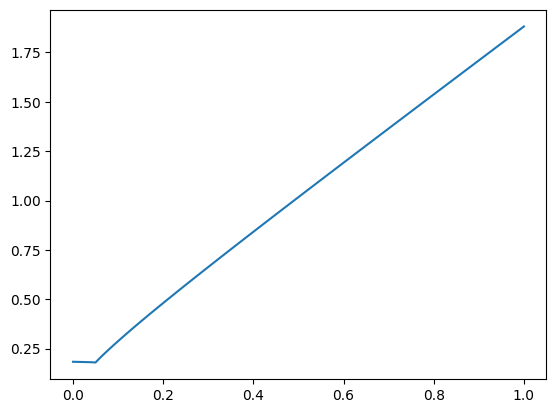

axial flows retentate side: [[8.66377977e-04 5.77585318e-04 0.00000000e+00]
 [6.50795612e-04 2.18223420e-04 3.04640749e-05]]
axial flows permeate side: [[0.00000000e+00 7.21981647e-05 0.00000000e+00]
 [2.48339188e-04 3.10622014e-04 2.79703286e-04]]
total balance per component: [-3.27568240e-05  1.20938049e-04 -3.10167361e-04]
elemental H balance: -0.0009960157298487524
elemental N balance: -6.829126248607351e-05
membrane flow retentate side: [-3.59924641e-04 -5.81588062e-06 -4.11616430e-04]
membrane flow permeate side: [-3.59924641e-04 -5.81588062e-06 -4.11616430e-04]


AttributeError: 'MembraneReactor' object has no attribute 'cnt_species_pressure'

In [ ]:
GHSV=150
H2_N2_ratio=1.5
sweep_ratio=0.05
r_min= 0.005
r_max =0.0165
L = 1.0
vol_reactor = np.pi * (r_max**2 - r_min**2) * L # volume

F_ret_in, F_perm_in, y_H2_in, y_N2_in = calculate_flows(GHSV, vol_reactor, sweep_ratio, H2_N2_ratio)
y_ret_in = [y_H2_in, y_N2_in, 0.0]

reactor = MembraneReactor(config_file = 'debug.json',
                L=L,
                r_min=r_min,
                r_max=r_max,
                F_ret_in=F_ret_in,
                F_perm_in=F_perm_in,
                y_ret_in=y_ret_in
            )
reactor.info()
    
p = reactor.c_p[...,-1]
p_vect = p.ravel()
p_perm = p[:, :reactor.num_r_perm]
p_ret = p[:, reactor.num_r_perm:]

#reactor.solve_adaptive(verbose=2)
dt_min = 1e-2
dt_init = None
reactor.solve(verbose=2, dt_min=1e-2)
#reactor.solve_adaptive_dt(dt_init=dt_init, dt_min=dt_min, verbose=2)
#reactor.solve_adaptive_react(verbose=2)

p_min = np.min(p)
p_max = np.max(p)
plt.pcolormesh(reactor.z_c, reactor.r_c_ret, p_ret[:, :].T)
plt.colorbar()
plt.pcolormesh(reactor.z_c, reactor.r_c_perm, p_perm[:, :].T)
plt.colorbar()
plt.show()

# plt.pcolormesh(reactor.z_c, reactor.r_c_ret, reactor.div_u[:, reactor.num_r_perm:].T)
# plt.colorbar()
# plt.pcolormesh(reactor.z_c, reactor.r_c_perm, reactor.div_u[:, :reactor.num_r_perm].T)
# plt.colorbar()
# plt.show()

# T_perm = reactor.T[:, :reactor.num_r_perm]
# T_ret = reactor.T[:, reactor.num_r_perm:]
# plt.pcolormesh(reactor.z_c, reactor.r_c_ret, T_ret[:, :].T)
# plt.colorbar()
# plt.pcolormesh(reactor.z_c, reactor.r_c_perm, T_perm[:, :].T)
# plt.colorbar()
# plt.show()

#k_f = reactor.kinetics.k_f
#plt.pcolormesh(reactor.z_c, reactor.r_c_ret, k_f.T)
#plt.colorbar()
#plt.show()

# c_perm = reactor.c_p[:, :reactor.num_r_perm,:-1]
# c_ret = reactor.c_p[:, reactor.num_r_perm:,:-1]
# plt.pcolormesh(reactor.z_c, reactor.r_c_ret, c_ret[:, :, 0].T)
# plt.colorbar()
# plt.show()
# plt.pcolormesh(reactor.z_c, reactor.r_c_perm, c_perm[:, :, 0].T)
# plt.colorbar()
# plt.show()

# plt.pcolormesh(reactor.z_f, reactor.r_c_ret, reactor.u_ret_ax.T)
# plt.colorbar()
# plt.pcolormesh(reactor.z_f, reactor.r_c_perm, reactor.u_perm_ax.T)
# plt.colorbar()
# plt.show()
# plt.plot(reactor.z_f, reactor.u_ret_ax[:, 0], '.')
# plt.plot(reactor.z_f, reactor.u_ret_ax[:, -1], '.')
# plt.show()
plt.plot(reactor.z_c, reactor.c_p[:, 0,-1], '-')
plt.plot(reactor.z_c, np.sum(reactor.c_p[:, 0,:-1],axis=-1)*8.314*reactor.T[:,0], 'o')
plt.show()

plt.plot(reactor.z_f, reactor.u_ret_ax[:, 0], '-')
plt.show()
plt.plot(reactor.z_f, reactor.u_perm_ax[:, 0], '-')
plt.show()


flows_ret_ax, flows_ret_mem, flows_perm_ax, flows_perm_mem = reactor.compute_flows()

print(f'axial flows retentate side: {flows_ret_ax[[0,-1],...]}')
print(f'axial flows permeate side: {flows_perm_ax[[0,-1],...]}')
flows_tot = flows_ret_ax[0,:] + flows_perm_ax[0,:] -  flows_ret_ax[-1,:] - flows_perm_ax[-1,:]
print(f'total balance per component: {flows_tot}')
print(f'elemental H balance: {2*flows_tot[0] + 3*flows_tot[2]}')
print(f'elemental N balance: {2*flows_tot[1] + flows_tot[2]}')

print(f'membrane flow retentate side: {flows_ret_mem}')
print(f'membrane flow permeate side: {flows_perm_mem}')

print(f'number of concentration solves: {reactor.cnt_num_solves_c_p}')
print(f'number of temperature solves: {reactor.cnt_num_solves_T}')

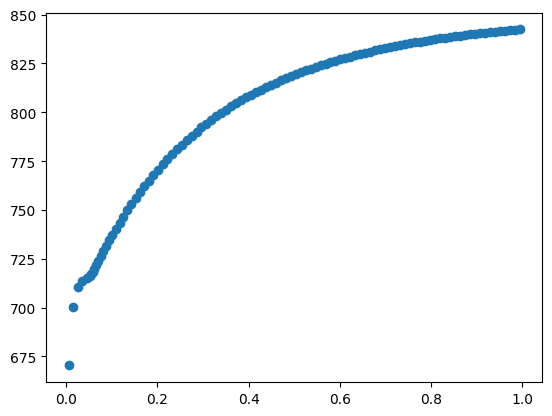

In [19]:
plt.plot(reactor.z_c, reactor.T[:,-1], 'o')
plt.show()

In [3]:
flows_ret_ax, flows_ret_mem, flows_perm_ax, flows_perm_mem = reactor.compute_flows()

print(f'axial flows retentate side: {flows_ret_ax}')
print(f'axial flows permeate side: {flows_perm_ax}')
flows_tot = flows_ret_ax[0,:] + flows_perm_ax[0,:] -  flows_ret_ax[-1,:] - flows_perm_ax[-1,:]
print(f'total balance per component: {flows_tot}')
print(f'elemental H balance: {2*flows_tot[0] + 3*flows_tot[2]}')
print(f'elemental N balance: {2*flows_tot[1] + flows_tot[2]}')

print(f'membrane flow retentate side: {flows_ret_mem}')
print(f'membrane flow permeate side: {flows_perm_mem}')

axial flows retentate side: [[8.66377977e-04 5.77585318e-04 0.00000000e+00]
 [8.16019701e-04 5.60799091e-04 3.35720308e-05]
 [7.70419682e-04 5.45596425e-04 6.39668125e-05]
 [7.53586911e-04 5.39977247e-04 7.51721550e-05]
 [7.49101733e-04 5.38467422e-04 7.81330852e-05]
 [7.47973085e-04 5.38074249e-04 7.88544804e-05]
 [7.46146171e-04 5.37696584e-04 7.66258932e-05]
 [7.43596800e-04 5.37109177e-04 7.47040496e-05]
 [7.40474643e-04 5.36365058e-04 7.28863695e-05]
 [7.36898728e-04 5.35506215e-04 7.10545789e-05]
 [7.32948196e-04 5.34561243e-04 6.91473153e-05]
 [7.28668693e-04 5.33547214e-04 6.71440929e-05]
 [7.24087398e-04 5.32474312e-04 6.50495435e-05]
 [7.19225253e-04 5.31349573e-04 6.28814900e-05]
 [7.14102870e-04 5.30178733e-04 6.06641124e-05]
 [7.08742641e-04 5.28967124e-04 5.84242111e-05]
 [7.03169902e-04 5.27720422e-04 5.61884459e-05]
 [6.97413565e-04 5.26445187e-04 5.39810676e-05]
 [6.91505530e-04 5.25148854e-04 5.18225742e-05]
 [6.85478977e-04 5.23839242e-04 4.97293606e-05]
 [6.79366466

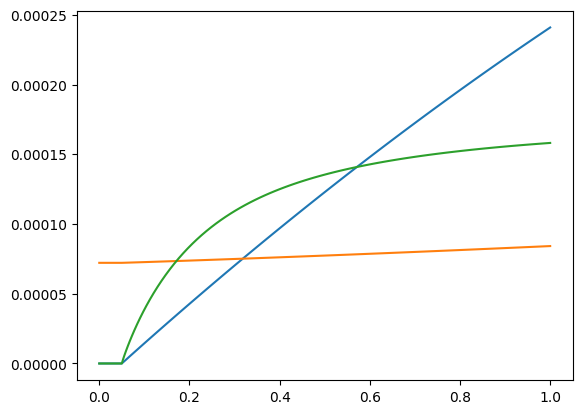

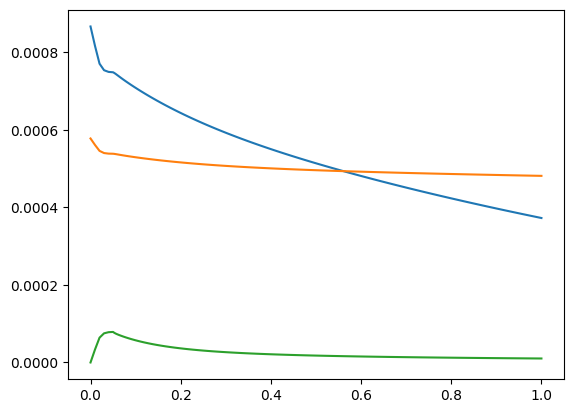

In [8]:
plt.plot(reactor.z_f, flows_perm_ax[:, 0])  
plt.plot(reactor.z_f, flows_perm_ax[:, 1])
plt.plot(reactor.z_f, flows_perm_ax[:, 2])

plt.show()

plt.plot(reactor.z_f, flows_ret_ax[:, 0])  
plt.plot(reactor.z_f, flows_ret_ax[:, 1])
plt.plot(reactor.z_f, flows_ret_ax[:, 2])
#plt.plot(reactor.z_f, flows_ret_ax[:, 0])

plt.show()

